In [1]:
import stim
import numpy as np

from spiderwarp.csscode import CSSCode
from spiderwarp.utils import load_state_prep_circuit
from spiderwarp.stim_utils import steane_se_from_stim_state_prep, get_num_measurements, perfect_state_from_code, \
    get_circuit_depth
from spiderwarp.path_cover import CoveredZXGraph
from spiderwarp.path_cover_metrics import metric_spacetime_volume_exact, metric_hardware_qubits_exact, metric_num_paths
from spiderwarp.qubit_reuse import build_circuit_dag, apply_logical_qubit_merge_and_compress, dag_to_circuit, inject_qubit_reuse, VolumeOptimizingReuseStrategy, AggressiveDepthAwareStrategy


%load_ext autoreload
%autoreload 2

In [2]:
code_dir, code_name, circ_dir, circ_path = "misc", "32_20_4", "misc", "alt_zero_32_20_4"
# code_dir, code_name, circ_dir, circ_path = "misc", "32_20_4", "boldi", "32_20_4"
code = CSSCode.load_code(code_dir, code_name)

perfect_state = perfect_state_from_code(code, "X")

test = perfect_state.copy()
test.append("MX", range(code.n))
print(test.compile_sampler().sample(10)[:,-code.n:] @ code.H_x.T % 2)

[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


Depth 58
Number of ancilla qubits necessary: 35


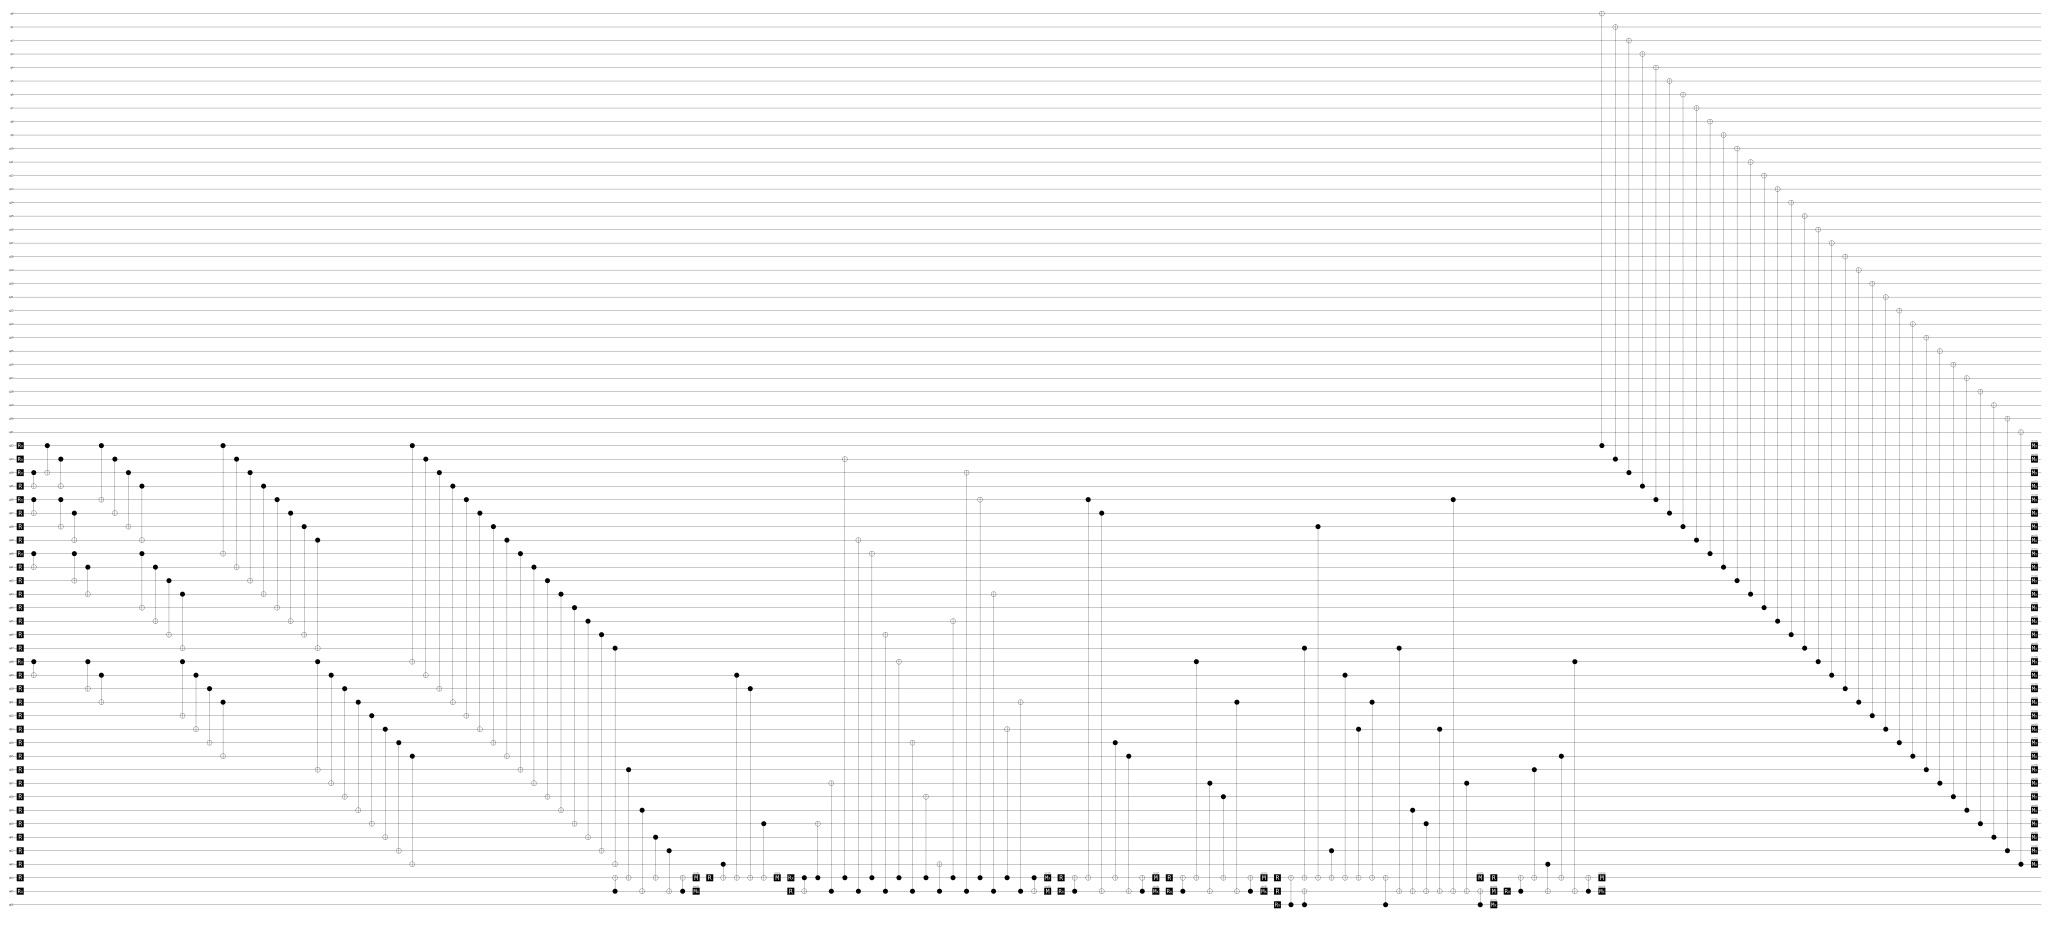

In [3]:
circuit = load_state_prep_circuit(circ_dir, circ_path)
se = steane_se_from_stim_state_prep(circuit, se_basis="Z", n=code.n)

print("Depth", get_circuit_depth(se))
print("Number of ancilla qubits necessary:", se.num_qubits - code.n)
with open("circ.svg", "w") as f:
    f.write(str(se.diagram('timeline-svg')))

se.diagram('timeline-svg')

In [4]:
print()

samples = (perfect_state + se).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]
print(samples[:,:-code.n].astype(int))
print(samples[:,-code.n:] @ code.H_z.T % 2)


[[0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


Depth 20
Number of ancilla qubits necessary: 46
Mapping of new measurements to old measurements: {0: 14, 1: 17, 2: 23, 3: 24, 4: 26, 5: 34, 6: 19, 7: 20, 8: 43, 9: 29, 10: 41, 11: 38, 12: 21, 13: 0, 14: 1, 15: 2, 16: 32, 17: 44, 18: 31, 19: 28, 20: 37, 21: 42, 22: 15, 23: 22, 24: 45, 25: 16, 26: 25, 27: 30, 28: 27, 29: 40, 30: 12, 31: 13, 32: 7, 33: 8, 34: 4, 35: 3, 36: 36, 37: 18, 38: 33, 39: 39, 40: 5, 41: 6, 42: 10, 43: 35, 44: 9, 45: 11}


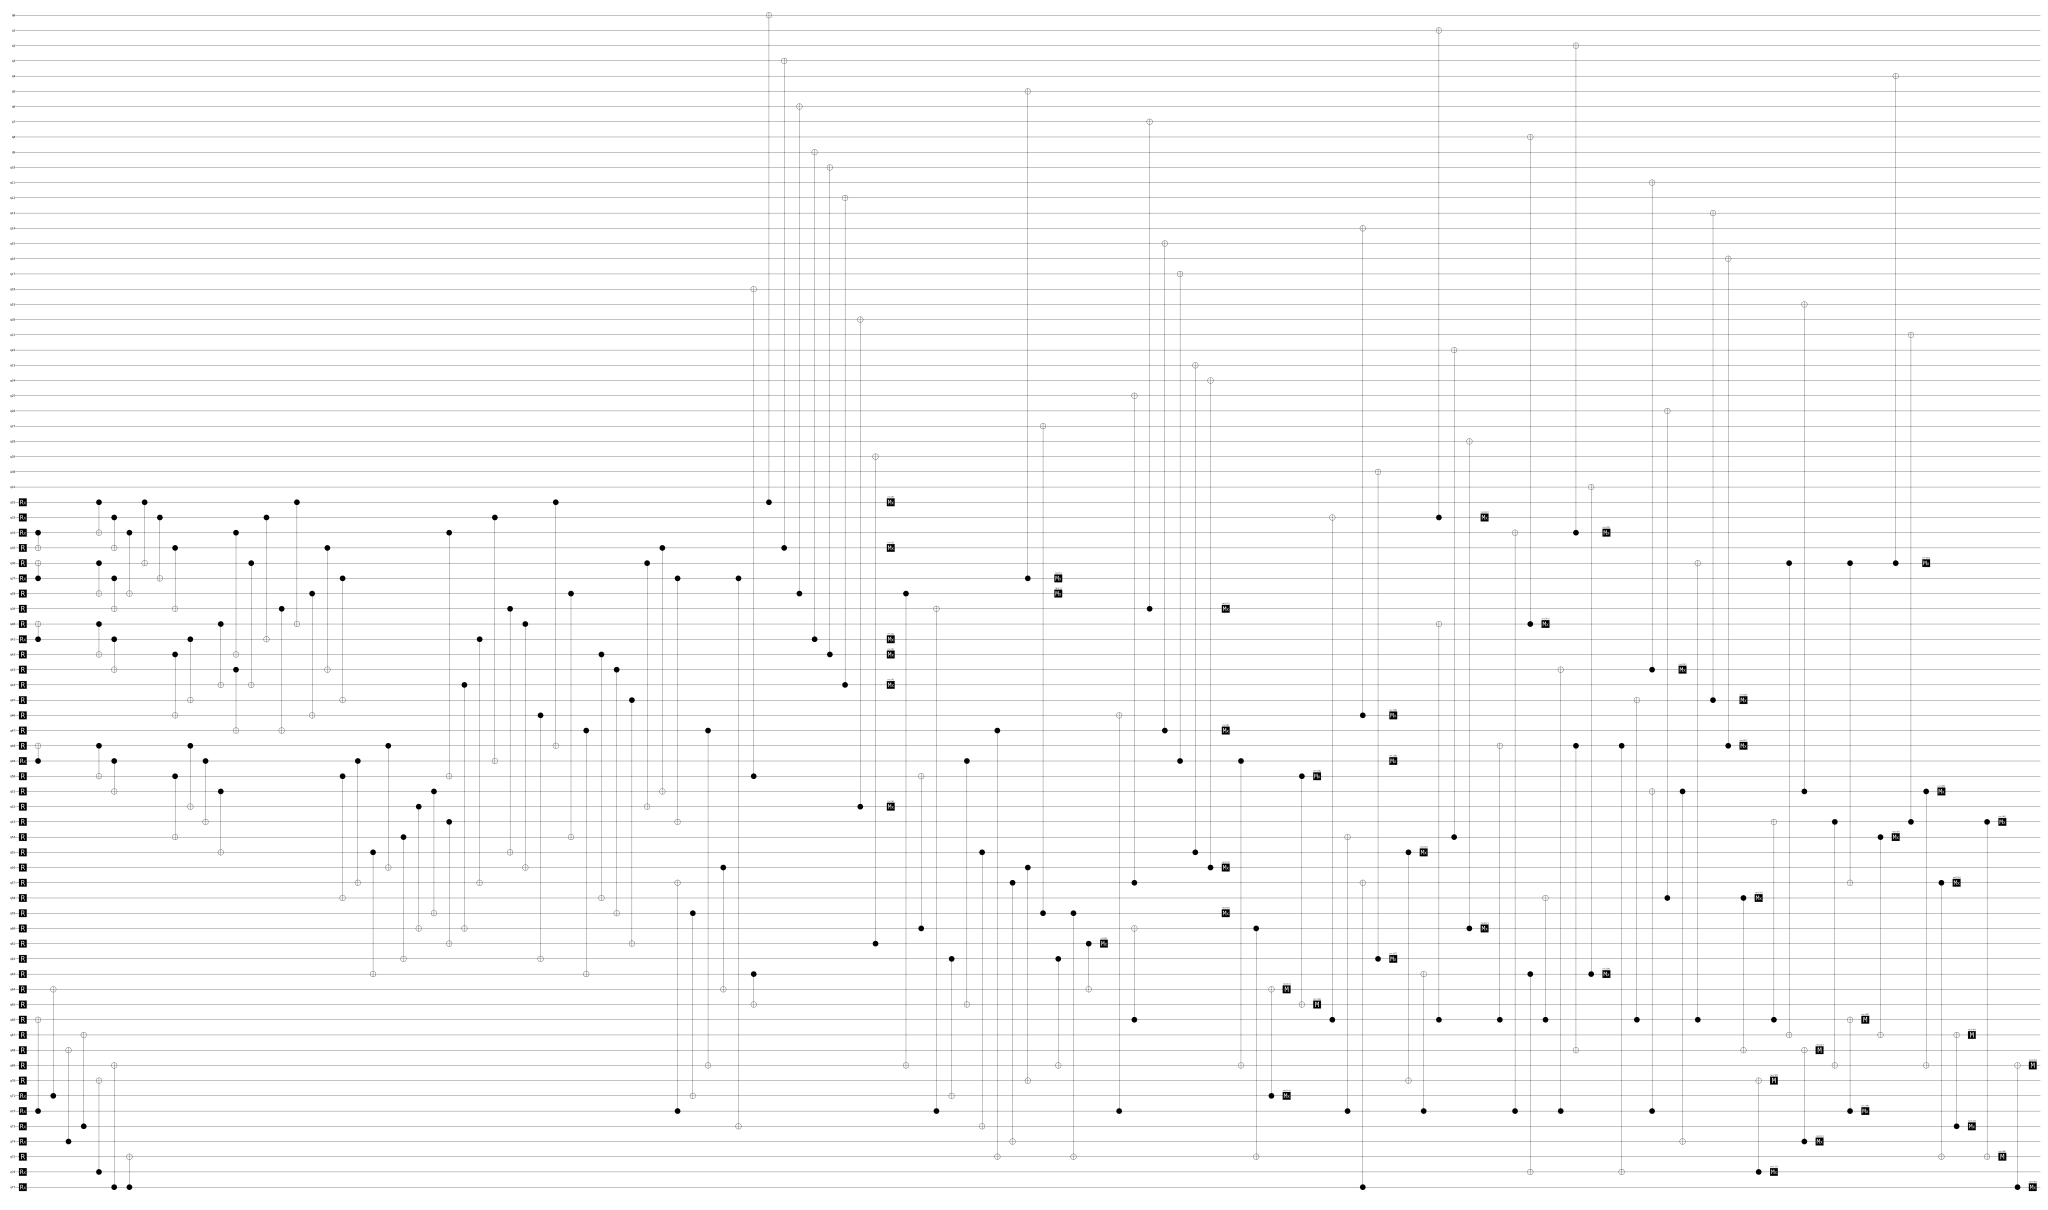

In [5]:
covered = CoveredZXGraph.from_stim(se)
covered.basic_FE_rewrites()
optimised = covered.greedy_best_first_boundary_bends(
    cost_func=metric_num_paths,
    # cost_func=metric_hardware_qubits_exact(AggressiveDepthAwareStrategy),
    # cost_func=metric_spacetime_volume_exact(VolumeOptimizingReuseStrategy),
    max_evaluations=1000
)
optimised = covered.shallow_copy()
optimised.optimize_path_extremities()
new_circuit, measurement_map = optimised.extract_circuit_with_measurement_map()

print("Depth",get_circuit_depth(new_circuit))

print("Number of ancilla qubits necessary:", new_circuit.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", measurement_map)
new_circuit.diagram('timeline-svg')

In [8]:
samples = (perfect_state + new_circuit).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
print("Number of ancilla qubits necessary:", num_measurements - code.n)
print(measurement_map)
flag_indices = [k for k, v in measurement_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print("Flags:", flags, sep="\n", end="\n\n")

syndrome_indices = {k: v - (num_measurements - code.n) for k, v in measurement_map.items() if v >= num_measurements - code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2


import numpy as np
np.set_printoptions(edgeitems=10, linewidth=400)
print(np.where(samples.astype(int).sum(axis=0) == 0))
print(flag_indices)

print("Syndromes:", syndromes, sep="\n")

Number of ancilla qubits necessary: 14
{0: 14, 1: 17, 2: 23, 3: 24, 4: 26, 5: 34, 6: 19, 7: 20, 8: 43, 9: 29, 10: 41, 11: 38, 12: 21, 13: 0, 14: 1, 15: 2, 16: 32, 17: 44, 18: 31, 19: 28, 20: 37, 21: 42, 22: 15, 23: 22, 24: 45, 25: 16, 26: 25, 27: 30, 28: 27, 29: 40, 30: 12, 31: 13, 32: 7, 33: 8, 34: 4, 35: 3, 36: 36, 37: 18, 38: 33, 39: 39, 40: 5, 41: 6, 42: 10, 43: 35, 44: 9, 45: 11}
Flags:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 1]]

(array([13, 14, 15, 30, 31, 32, 33, 35, 40, 41, 42, 44]),)
[13, 14, 15, 30, 31, 32, 33, 34, 35, 40, 41, 42, 44, 45]
Syndromes:
[[1 1 1 0 1 1]
 [0 1 1 0 0 0]
 [1 0 0 0 1 1]
 [1 0 0 0 1 1]
 [0 0 0 0 0 0]
 [1 0 0 0 1 1]
 [0 0 0 0 0 0]
 [1 1 1 0 1 1]
 [0 1 1 0 0 0]
 [0 1 1 0 0 0]]


Number of ancilla qubits necessary: 30
Mapping of new measurements to old measurements: {0: 17, 1: 29, 2: 41, 3: 23, 4: 19, 5: 21, 6: 28, 7: 20, 8: 44, 9: 24, 10: 31, 11: 16, 12: 25, 13: 26, 14: 34, 15: 2, 16: 32, 17: 42, 18: 15, 19: 14, 20: 43, 21: 22, 22: 0, 23: 1, 24: 27, 25: 4, 26: 3, 27: 36, 28: 40, 29: 5, 30: 6, 31: 7, 32: 8, 33: 33, 34: 18, 35: 39, 36: 9, 37: 11, 38: 10, 39: 35, 40: 38, 41: 37, 42: 45, 43: 30, 44: 12, 45: 13}


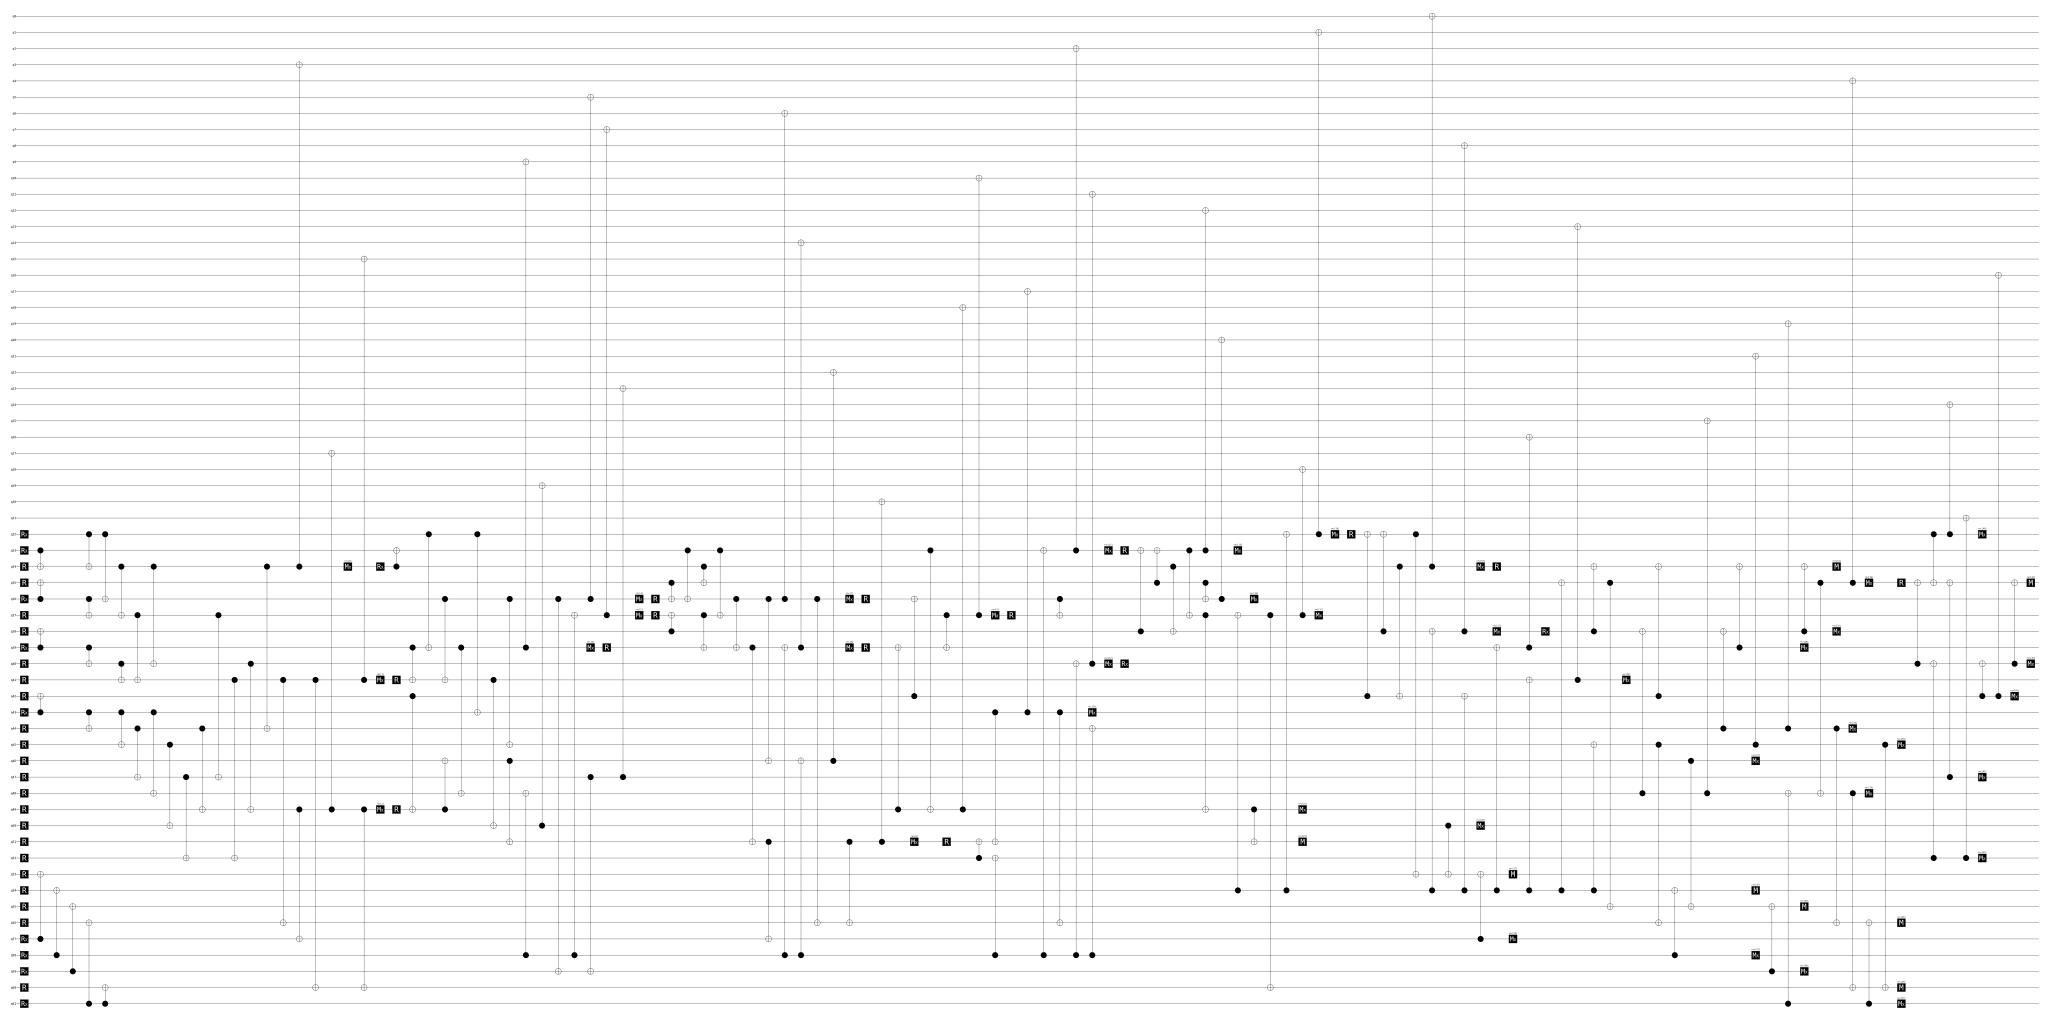

In [9]:
dag = build_circuit_dag(optimised)

mod_dag, logical_to_physical, total_hw = inject_qubit_reuse(dag, code.n, AggressiveDepthAwareStrategy())
compressed_dag = apply_logical_qubit_merge_and_compress(mod_dag, code.n)
final_circ, final_meas_map = dag_to_circuit(compressed_dag)

print("Number of ancilla qubits necessary:", final_circ.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", final_meas_map)
final_circ.diagram('timeline-svg')

In [10]:
samples = (perfect_state + final_circ).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
flag_indices = [k for k, v in final_meas_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print("Flags:", flags, sep="\n", end="\n\n")

syndrome_indices = {k: v - (num_measurements - code.n) for k, v in final_meas_map.items() if v >= num_measurements - code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Syndromes:", syndromes, sep="\n")

Flags:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0]]

Syndromes:
[[0 0 0 0 0 0]
 [0 1 1 0 0 0]
 [0 1 1 0 0 0]
 [1 1 1 0 1 1]
 [0 0 0 0 0 0]
 [0 1 1 0 0 0]
 [1 0 0 0 1 1]
 [1 0 0 0 1 1]
 [1 0 0 0 1 1]
 [1 1 1 0 1 1]]


In [11]:
from spiderwarp.stim_utils import get_circuit_depth, get_spacetime_volume

print(get_circuit_depth(se), get_spacetime_volume(se))
print(get_circuit_depth(final_circ), get_spacetime_volume(final_circ))

58 3886
63 3906


In [12]:
# OG: 34 ancilla, 60 depth, 3960 circuit volume
# AGGRESSIVE DEPTH AWARE: 32 ancilla, 59 depth, 3776 circuit volume
# VolumeOptimizing

final_circ.num_qubits - 32

30

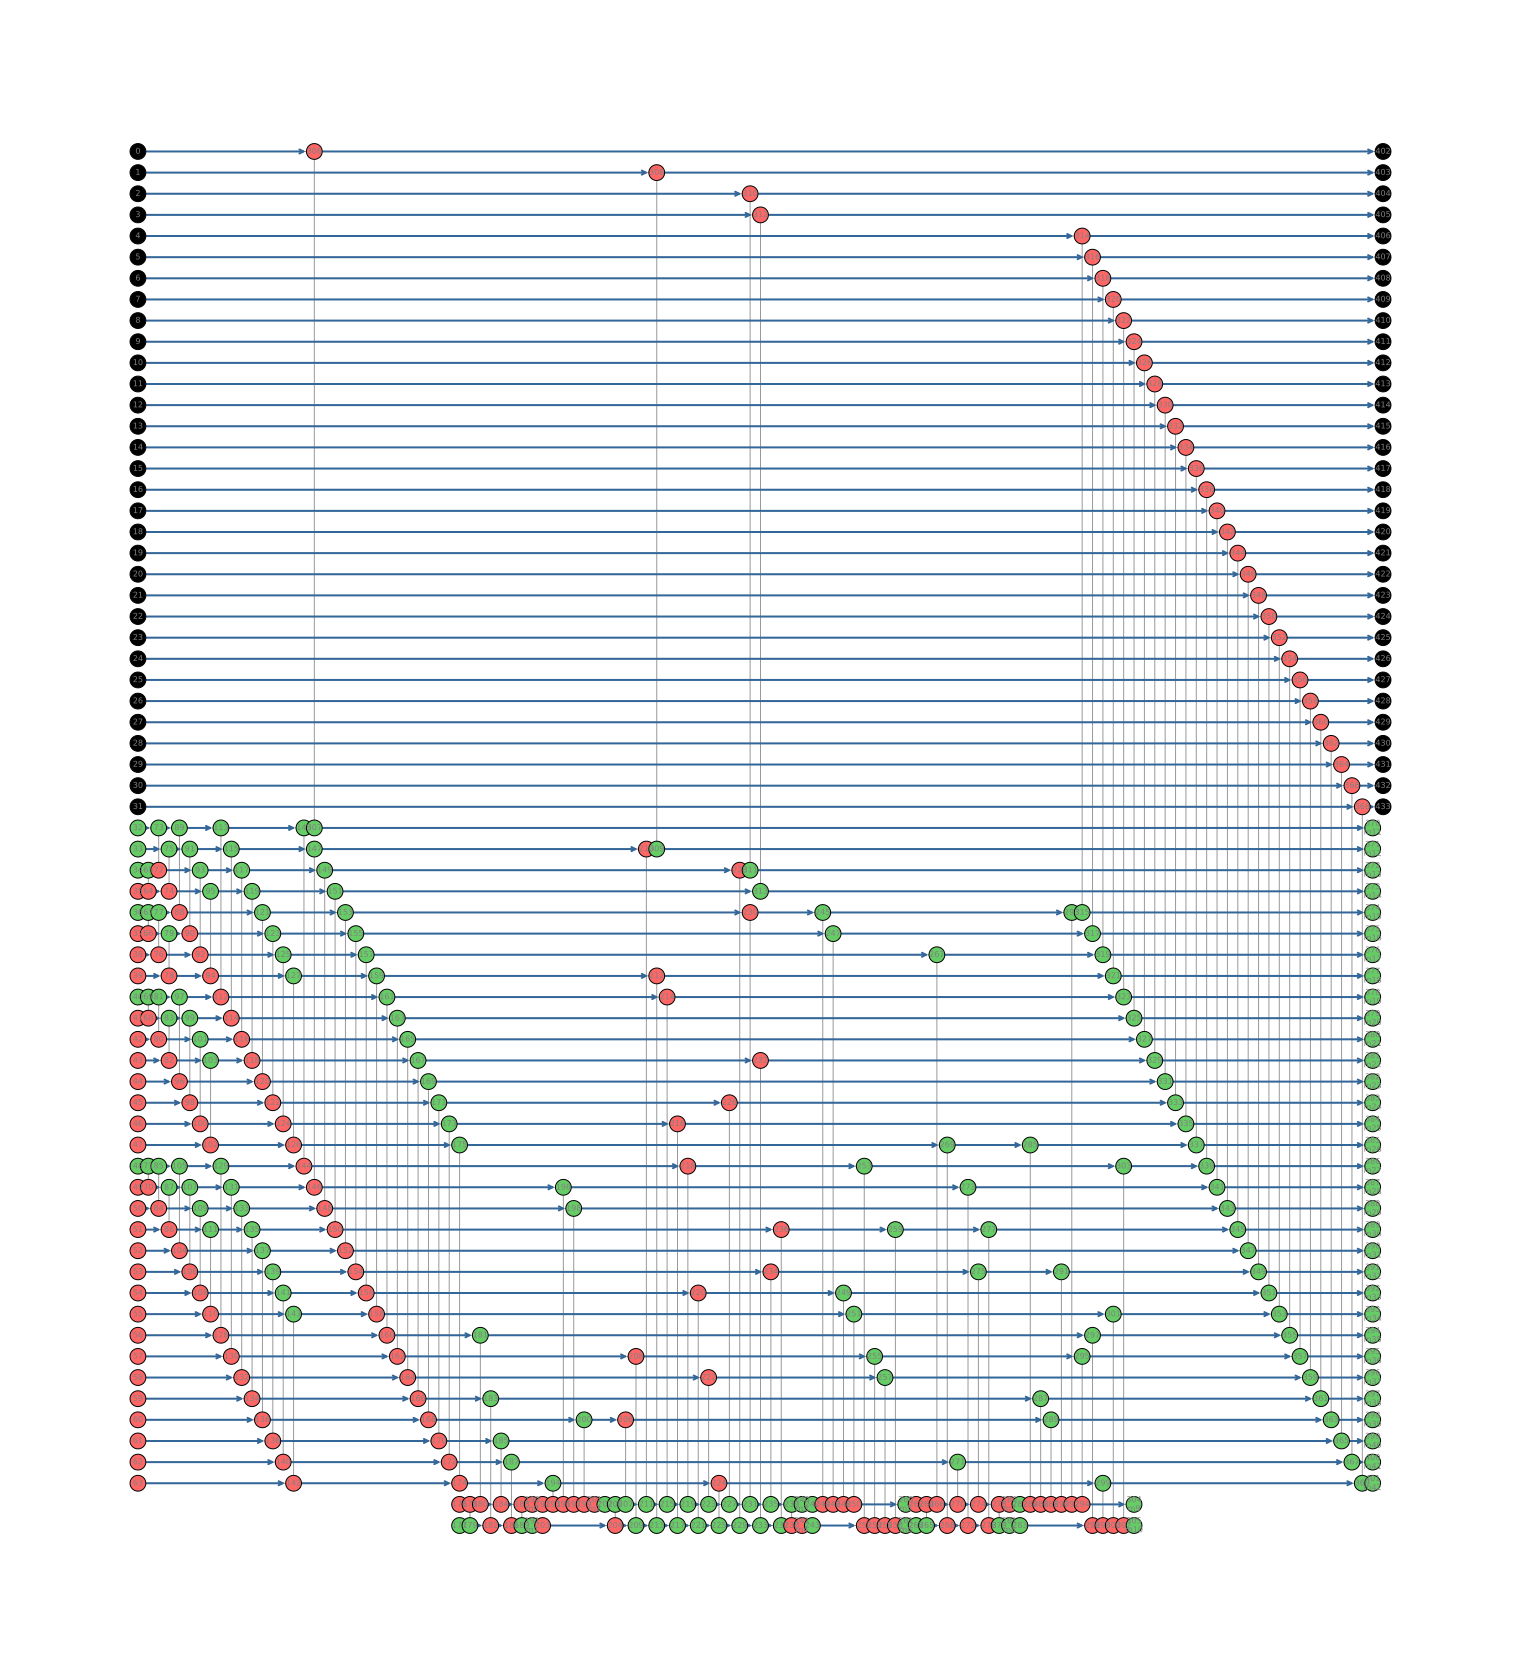

In [144]:
CoveredZXGraph.from_stim(se).visualize(figsize = (27, 30))